In [2]:
!pip install -q pydicom
import glob, os
import pandas as pd
import pydicom

hits = glob.glob("/kaggle/input/**/stage_2_train_labels.csv", recursive=True)
assert hits, "Data not found. Check that the RSNA competition data is attached."
DATA = os.path.dirname(hits[0])
print("Data folder:", DATA)
print("Contents:", os.listdir(DATA))

labels = pd.read_csv(f"{DATA}/stage_2_train_labels.csv")
info = pd.read_csv(f"{DATA}/stage_2_detailed_class_info.csv").drop_duplicates()

print("\nRows in labels file:", len(labels))
print("Unique patients:", labels.patientId.nunique())
print("Image files:", len(os.listdir(f"{DATA}/stage_2_train_images")))

per_patient = labels.groupby("patientId").Target.max()
print("\nPatients with pneumonia boxes:", int(per_patient.sum()))
print("Patients without:", int((per_patient == 0).sum()))

print("\nBoxes per pneumonia patient:")
print(labels[labels.Target == 1].groupby("patientId").size().value_counts().sort_index())

print("\nDetailed classes (one per patient):")
print(info["class"].value_counts())

print("\nFirst rows of labels:")
print(labels.head())

Data folder: /kaggle/input/competitions/rsna-pneumonia-detection-challenge
Contents: ['stage_2_train_images', 'stage_2_sample_submission.csv', 'stage_2_detailed_class_info.csv', 'GCP Credits Request Link - RSNA.txt', 'stage_2_train_labels.csv', 'stage_2_test_images']

Rows in labels file: 30227
Unique patients: 26684
Image files: 26684

Patients with pneumonia boxes: 6012
Patients without: 20672

Boxes per pneumonia patient:
1    2614
2    3266
3     119
4      13
Name: count, dtype: int64

Detailed classes (one per patient):
class
No Lung Opacity / Not Normal    11821
Normal                           8851
Lung Opacity                     6012
Name: count, dtype: int64

First rows of labels:
                              patientId      x      y  width  height  Target
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6    NaN    NaN    NaN     NaN       0
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd    NaN    NaN    NaN     NaN       0
2  00322d4d-1c29-4943-afc9-b6754be640eb    NaN    NaN    NaN     NaN

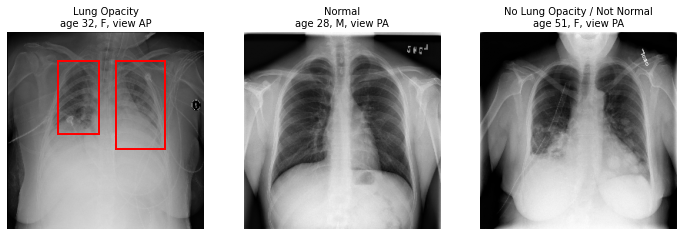

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), dpi=72)
for ax, cls in zip(axes, ["Lung Opacity", "Normal", "No Lung Opacity / Not Normal"]):
    pid = info[info["class"] == cls].patientId.iloc[0]
    ds = pydicom.dcmread(f"{DATA}/stage_2_train_images/{pid}.dcm")
    img = ds.pixel_array[::4, ::4]         
    ax.imshow(img, cmap="gray")
    for _, r in labels[(labels.patientId == pid) & (labels.Target == 1)].iterrows():
        ax.add_patch(patches.Rectangle((r.x / 4, r.y / 4), r.width / 4, r.height / 4,
                                       fill=False, edgecolor="red", linewidth=2))
    ax.set_title(f"{cls}\nage {ds.PatientAge}, {ds.PatientSex}, view {ds.ViewPosition}", fontsize=10)
    ax.axis("off")
plt.show()

In [4]:
from tqdm.auto import tqdm

rows = []
for pid in tqdm(info.patientId):
    ds = pydicom.dcmread(f"{DATA}/stage_2_train_images/{pid}.dcm", stop_before_pixels=True)
    rows.append({"patientId": pid, "age": str(ds.PatientAge),
                 "sex": str(ds.PatientSex), "view": str(ds.ViewPosition)})
meta = pd.DataFrame(rows)
meta["age"] = pd.to_numeric(meta["age"].str.extract(r"(\d+)")[0], errors="coerce")
print("Done:", len(meta), "patients")

  0%|          | 0/26684 [00:00<?, ?it/s]

Done: 26684 patients


In [5]:
from sklearn.model_selection import train_test_split

df = info.merge(meta, on="patientId")
df["target"] = (df["class"] == "Lung Opacity").astype(int)
boxes = labels[labels.Target == 1].groupby("patientId").size()
df["n_boxes"] = df.patientId.map(boxes).fillna(0).astype(int)

train_val, test = train_test_split(df, test_size=0.20, stratify=df["class"], random_state=42)
train, val = train_test_split(train_val, test_size=0.125, stratify=train_val["class"], random_state=42)
df["split"] = "train"
df.loc[val.index, "split"] = "val"
df.loc[test.index, "split"] = "test"

print("Patients per split, and share with pneumonia:")
print(df.groupby("split").agg(patients=("target", "size"),
                              pneumonia=("target", "sum"),
                              pneumonia_rate=("target", "mean")).round(3))

print("\nClasses per split:")
print(pd.crosstab(df["split"], df["class"]))

print("\nPatients appearing in more than one split:", int(df.patientId.duplicated().sum()))

print("\nX-ray view by class (number of patients):")
print(pd.crosstab(df["view"], df["class"]))
print("\nPneumonia rate by view:")
print(df.groupby("view").target.mean().round(3))

print("\nSex:")
print(df.sex.value_counts())
print("\nAge:")
print(df.age.describe().round(1))
print("Ages over 100:", int((df.age > 100).sum()))

df.to_csv("/kaggle/working/splits.csv", index=False)
print("\nSaved splits.csv with columns:", list(df.columns))

Patients per split, and share with pneumonia:
       patients  pneumonia  pneumonia_rate
split                                     
test       5337       1203           0.225
train     18678       4208           0.225
val        2669        601           0.225

Classes per split:
class  Lung Opacity  No Lung Opacity / Not Normal  Normal
split                                                    
test           1203                          2364    1770
train          4208                          8274    6196
val             601                          1183     885

Patients appearing in more than one split: 0

X-ray view by class (number of patients):
class  Lung Opacity  No Lung Opacity / Not Normal  Normal
view                                                     
AP             4664                          5872    1637
PA             1348                          5949    7214

Pneumonia rate by view:
view
AP    0.383
PA    0.093
Name: target, dtype: float64

Sex:
sex
M    15166
F   

In [6]:
import numpy as np, cv2
from collections import Counter
from joblib import Parallel, delayed

SIZE = 384

def load_small(pid):
    ds = pydicom.dcmread(f"{DATA}/stage_2_train_images/{pid}.dcm")
    img = ds.pixel_array
    ok = (img.shape == (1024, 1024)) and (img.dtype == np.uint8)
    small = cv2.resize(img, (SIZE, SIZE), interpolation=cv2.INTER_AREA)
    return small, ok, str(ds.PhotometricInterpretation)

out = Parallel(n_jobs=4)(delayed(load_small)(pid) for pid in tqdm(df.patientId))
images = np.stack([o[0] for o in out])

print("Images that are not 1024x1024, 8-bit:", sum(not o[1] for o in out))
print("Greyscale type (should be one kind only):", dict(Counter(o[2] for o in out)))
del out

b = labels[labels.Target == 1]
outside = ((b.x < 0) | (b.y < 0) | (b.x + b.width > 1024) | (b.y + b.height > 1024)).sum()
print("Boxes reaching outside the image:", int(outside), "of", len(b))
print("Smallest box (width x height):", int(b.width.min()), "x", int(b.height.min()))
print("Share of the image covered by a box, median:", round(float((b.width * b.height).median() / 1024**2), 3))

df["idx"] = np.arange(len(df))         
sample = images[df[df.split == "train"].idx.sample(2000, random_state=42).sort_values().values] / 255.0
print("\nTrain pixel mean and std (2,000 images):", round(float(sample.mean()), 3), round(float(sample.std()), 3))

np.save("/kaggle/working/images_384.npy", images)
df.to_csv("/kaggle/working/splits.csv", index=False)
print("\nSaved:", images.shape, images.dtype, "|", round(images.nbytes / 1e9, 2), "GB")

  0%|          | 0/26684 [00:00<?, ?it/s]

Images that are not 1024x1024, 8-bit: 0
Greyscale type (should be one kind only): {'MONOCHROME2': 26684}
Boxes reaching outside the image: 0 of 9555
Smallest box (width x height): 40 x 45
Share of the image covered by a box, median: 0.062

Train pixel mean and std (2,000 images): 0.49 0.247

Saved: (26684, 384, 384) uint8 | 3.93 GB
